Análise de Viés em Machine Learning aplicado ao Marketing Bancário

In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn

Importação das Bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Carregamento dos Datasets

Dois datasets são utilizados: o Bank Marketing Dataset (Portugal, UCI) e o Churn Modelling Dataset (Europa).

In [ ]:
df_pt = pd.read_csv('../dados/Bank Marketing/bank-additional-full.csv', sep=';')
df_churn = pd.read_csv('../dados/Churn/Churn_Modelling.csv')

Análise Exploratória Inicial
Visualização das primeiras linhas

In [ ]:
print(df_pt.head())
print(df_churn.head())

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

Tamanho dos Datasets

In [ ]:
print(f"Portugal: {df_pt.shape}")
print(f"Churn: {df_churn.shape}")

Portugal: (41188, 21)
Churn: (10000, 14)


Verificação de Valores Nulos

In [ ]:
print(df_pt.isnull().sum())
print(df_churn.isnull().sum())

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


Distribuição da Variável Alvo
Verificação do balanceamento das classes em cada dataset

In [9]:
print("=== PORTUGAL — variável alvo (y) ===")
print(df_pt['y'].value_counts())
print(df_pt['y'].value_counts(normalize=True).round(3))

print("\n=== CHURN — variável alvo (Exited) ===")
print(df_churn['Exited'].value_counts())
print(df_churn['Exited'].value_counts(normalize=True).round(3))

=== PORTUGAL — variável alvo (y) ===
y
no     36548
yes     4640
Name: count, dtype: int64
y
no     0.887
yes    0.113
Name: proportion, dtype: float64

=== CHURN — variável alvo (Exited) ===
Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    0.796
1    0.204
Name: proportion, dtype: float64


Visualização do Desbalanceamento das Classes

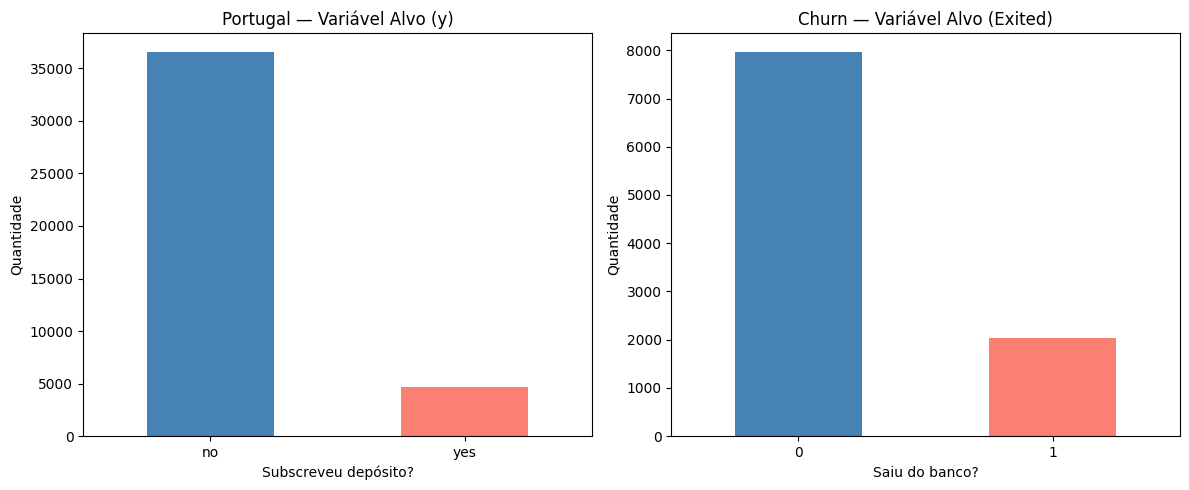

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Portugal
df_pt['y'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Portugal — Variável Alvo (y)')
axes[0].set_xlabel('Subscreveu depósito?')
axes[0].set_ylabel('Quantidade')
axes[0].tick_params(rotation=0)

# Churn
df_churn['Exited'].value_counts().plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'])
axes[1].set_title('Churn — Variável Alvo (Exited)')
axes[1].set_xlabel('Saiu do banco?')
axes[1].set_ylabel('Quantidade')
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.savefig('../figuras/distribuicao_classes.png', dpi=150)
plt.show()

Distribuição das Variáveis Sensíveis

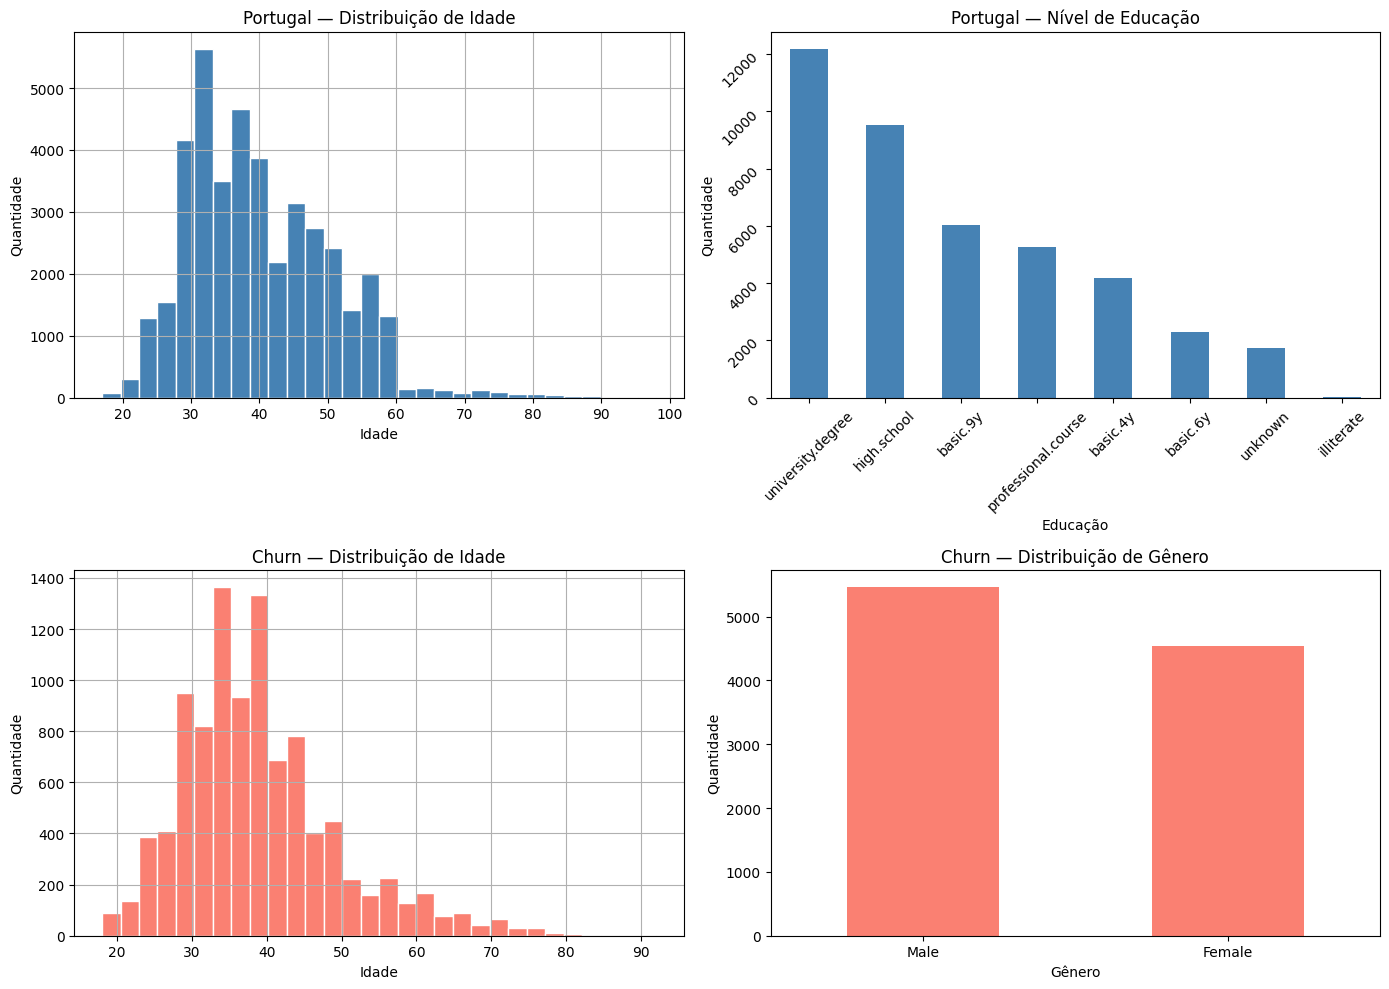

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Portugal — Idade
df_pt['age'].hist(ax=axes[0,0], bins=30, color='steelblue', edgecolor='white')
axes[0,0].set_title('Portugal — Distribuição de Idade')
axes[0,0].set_xlabel('Idade')
axes[0,0].set_ylabel('Quantidade')

# Portugal — Educação
df_pt['education'].value_counts().plot(kind='bar', ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Portugal — Nível de Educação')
axes[0,1].set_xlabel('Educação')
axes[0,1].set_ylabel('Quantidade')
axes[0,1].tick_params(rotation=45)

# Churn — Idade
df_churn['Age'].hist(ax=axes[1,0], bins=30, color='salmon', edgecolor='white')
axes[1,0].set_title('Churn — Distribuição de Idade')
axes[1,0].set_xlabel('Idade')
axes[1,0].set_ylabel('Quantidade')

# Churn — Gênero
df_churn['Gender'].value_counts().plot(kind='bar', ax=axes[1,1], color='salmon')
axes[1,1].set_title('Churn — Distribuição de Gênero')
axes[1,1].set_xlabel('Gênero')
axes[1,1].set_ylabel('Quantidade')
axes[1,1].tick_params(rotation=0)

plt.tight_layout()
plt.savefig('../figuras/variaveis_sensiveis.png', dpi=150)
plt.show()

Relação entre Variáveis Sensíveis e Variável Alvo

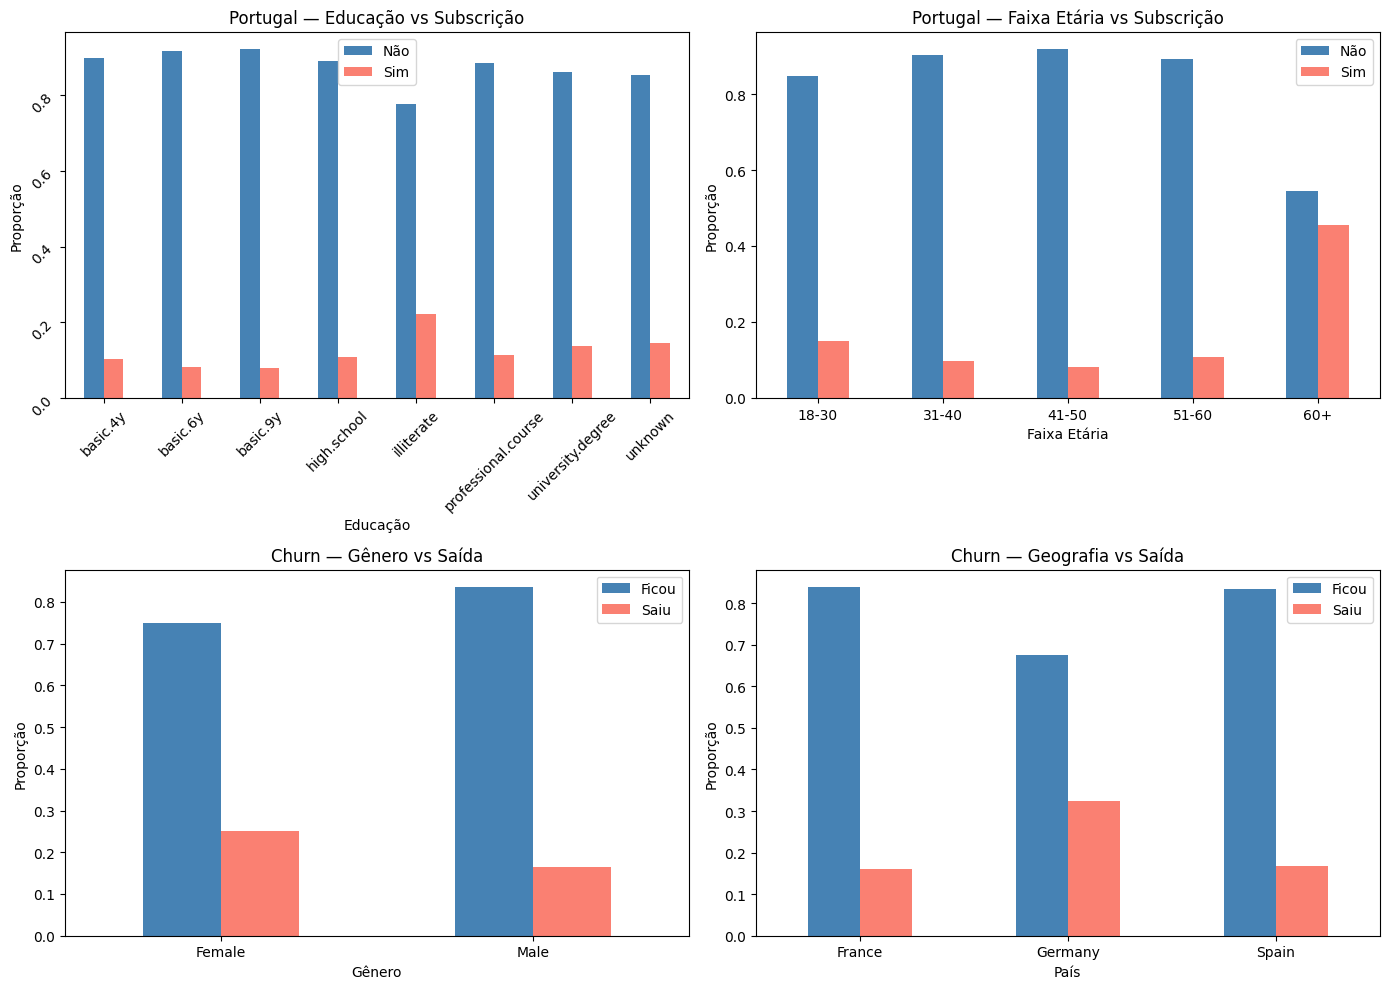

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Portugal — Educação vs y
edu_counts = df_pt.groupby('education')['y'].value_counts(normalize=True).unstack()
edu_counts.plot(kind='bar', ax=axes[0,0], color=['steelblue', 'salmon'])
axes[0,0].set_title('Portugal — Educação vs Subscrição')
axes[0,0].set_xlabel('Educação')
axes[0,0].set_ylabel('Proporção')
axes[0,0].tick_params(rotation=45)
axes[0,0].legend(['Não', 'Sim'])

# Portugal — Faixa etária vs y
df_pt['faixa_etaria'] = pd.cut(df_pt['age'], bins=[18,30,40,50,60,100], 
                                labels=['18-30','31-40','41-50','51-60','60+'])
age_counts = df_pt.groupby('faixa_etaria', observed=True)['y'].value_counts(normalize=True).unstack()
age_counts.plot(kind='bar', ax=axes[0,1], color=['steelblue', 'salmon'])
axes[0,1].set_title('Portugal — Faixa Etária vs Subscrição')
axes[0,1].set_xlabel('Faixa Etária')
axes[0,1].set_ylabel('Proporção')
axes[0,1].tick_params(rotation=0)
axes[0,1].legend(['Não', 'Sim'])

# Churn — Gênero vs Exited
gen_counts = df_churn.groupby('Gender')['Exited'].value_counts(normalize=True).unstack()
gen_counts.plot(kind='bar', ax=axes[1,0], color=['steelblue', 'salmon'])
axes[1,0].set_title('Churn — Gênero vs Saída')
axes[1,0].set_xlabel('Gênero')
axes[1,0].set_ylabel('Proporção')
axes[1,0].tick_params(rotation=0)
axes[1,0].legend(['Ficou', 'Saiu'])

# Churn — Geografia vs Exited
geo_counts = df_churn.groupby('Geography')['Exited'].value_counts(normalize=True).unstack()
geo_counts.plot(kind='bar', ax=axes[1,1], color=['steelblue', 'salmon'])
axes[1,1].set_title('Churn — Geografia vs Saída')
axes[1,1].set_xlabel('País')
axes[1,1].set_ylabel('Proporção')
axes[1,1].tick_params(rotation=0)
axes[1,1].legend(['Ficou', 'Saiu'])

plt.tight_layout()
plt.savefig('../figuras/variaveis_vs_alvo.png', dpi=150)
plt.show()

Estatísticas Descritivas

In [13]:
print("=== PORTUGAL ===")
print(df_pt.describe())

print("\n=== CHURN ===")
print(df_churn.describe())

=== PORTUGAL ===
               age      duration      campaign         pdays      previous  \
count  41188.00000  41188.000000  41188.000000  41188.000000  41188.000000   
mean      40.02406    258.285010      2.567593    962.475454      0.172963   
std       10.42125    259.279249      2.770014    186.910907      0.494901   
min       17.00000      0.000000      1.000000      0.000000      0.000000   
25%       32.00000    102.000000      1.000000    999.000000      0.000000   
50%       38.00000    180.000000      2.000000    999.000000      0.000000   
75%       47.00000    319.000000      3.000000    999.000000      0.000000   
max       98.00000   4918.000000     56.000000    999.000000      7.000000   

       emp.var.rate  cons.price.idx  cons.conf.idx     euribor3m   nr.employed  
count  41188.000000    41188.000000   41188.000000  41188.000000  41188.000000  
mean       0.081886       93.575664     -40.502600      3.621291   5167.035911  
std        1.570960        0.578840  

Pré-processamento dos Dados
Removendo colunas desnecessárias

In [14]:
# Portugal — remover coluna 'duration' 
# (só é conhecida após a ligação, causa vazamento de dados)
df_pt = df_pt.drop(columns=['duration', 'faixa_etaria'])

# Churn — remover colunas de identificação
df_churn = df_churn.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

print("Portugal — colunas restantes:", df_pt.shape[1])
print("Churn — colunas restantes:", df_churn.shape[1])

Portugal — colunas restantes: 20
Churn — colunas restantes: 11


Codificação das Variáveis Categóricas

In [15]:
# verificar quais colunas são categóricas
print("=== PORTUGAL — categóricas ===")
print(df_pt.select_dtypes(include='object').columns.tolist())

print("\n=== CHURN — categóricas ===")
print(df_churn.select_dtypes(include='object').columns.tolist())

=== PORTUGAL — categóricas ===
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']

=== CHURN — categóricas ===
['Geography', 'Gender']


C:\Users\Pichau\AppData\Local\Temp\ipykernel_28444\863982777.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df_pt.select_dtypes(include='object').columns.tolist())
C:\Users\Pichau\AppData\Local\Temp\ipykernel_28444\863982777.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user

Aplicando One-Hot Encoding nas variáveis categóricas

In [16]:
# Portugal — codificar variável alvo separadamente
df_pt['y'] = df_pt['y'].map({'yes': 1, 'no': 0})

# Portugal — One-Hot nas demais categóricas
df_pt = pd.get_dummies(df_pt, columns=['job', 'marital', 'education', 'default',
                                        'housing', 'loan', 'contact',
                                        'month', 'day_of_week', 'poutcome'])

# Churn — codificar Gender
df_churn['Gender'] = df_churn['Gender'].map({'Male': 1, 'Female': 0})

# Churn — One-Hot na Geography
df_churn = pd.get_dummies(df_churn, columns=['Geography'])

print("Portugal — shape final:", df_pt.shape)
print("Churn — shape final:", df_churn.shape)

Portugal — shape final: (41188, 63)
Churn — shape final: (10000, 13)


Separando features e variável alvo / Divisão Treino e Teste

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Portugal
X_pt = df_pt.drop(columns=['y'])
y_pt = df_pt['y']

X_train_pt, X_test_pt, y_train_pt, y_test_pt = train_test_split(
    X_pt, y_pt, test_size=0.2, random_state=42, stratify=y_pt)

# Churn
X_churn = df_churn.drop(columns=['Exited'])
y_churn = df_churn['Exited']

X_train_churn, X_test_churn, y_train_churn, y_test_churn = train_test_split(
    X_churn, y_churn, test_size=0.2, random_state=42, stratify=y_churn)

print("Portugal — Treino:", X_train_pt.shape, "| Teste:", X_test_pt.shape)
print("Churn — Treino:", X_train_churn.shape, "| Teste:", X_test_churn.shape)

Portugal — Treino: (32950, 62) | Teste: (8238, 62)
Churn — Treino: (8000, 12) | Teste: (2000, 12)


Normalização dos dados

In [18]:
scaler = StandardScaler()

# Portugal
X_train_pt = scaler.fit_transform(X_train_pt)
X_test_pt = scaler.transform(X_test_pt)

# Churn
scaler2 = StandardScaler()
X_train_churn = scaler2.fit_transform(X_train_churn)
X_test_churn = scaler2.transform(X_test_churn)

print("Normalização concluída!")
print(f"Portugal — média após normalização: {X_train_pt.mean():.4f}")
print(f"Churn — média após normalização: {X_train_churn.mean():.4f}")

Normalização concluída!
Portugal — média após normalização: 0.0000
Churn — média após normalização: -0.0000


Treinamento dos Modelos
Regressão Logística

In [19]:
from sklearn.linear_model import LogisticRegression

# Portugal
lr_pt = LogisticRegression(max_iter=1000, random_state=42)
lr_pt.fit(X_train_pt, y_train_pt)

# Churn
lr_churn = LogisticRegression(max_iter=1000, random_state=42)
lr_churn.fit(X_train_churn, y_train_churn)

print("Regressão Logística treinada!")

Regressão Logística treinada!


Árvore de Decisão

In [20]:
from sklearn.tree import DecisionTreeClassifier

# Portugal
dt_pt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_pt.fit(X_train_pt, y_train_pt)

# Churn
dt_churn = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_churn.fit(X_train_churn, y_train_churn)

print("Árvore de Decisão treinada!")

Árvore de Decisão treinada!


Random Forest

In [21]:
from sklearn.ensemble import RandomForestClassifier

# Portugal
rf_pt = RandomForestClassifier(n_estimators=100, random_state=42)
rf_pt.fit(X_train_pt, y_train_pt)

# Churn
rf_churn = RandomForestClassifier(n_estimators=100, random_state=42)
rf_churn.fit(X_train_churn, y_train_churn)

print("Random Forest treinado!")

Random Forest treinado!


Avaliação dos Modelos
Métricas gerais

In [22]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

modelos_pt = {
    'Regressão Logística': lr_pt,
    'Árvore de Decisão': dt_pt,
    'Random Forest': rf_pt
}

modelos_churn = {
    'Regressão Logística': lr_churn,
    'Árvore de Decisão': dt_churn,
    'Random Forest': rf_churn
}

print("=== PORTUGAL ===")
print(f"{'Modelo':<25} {'Acurácia':>10} {'F1-Score':>10} {'ROC-AUC':>10}")
print("-" * 60)
for nome, modelo in modelos_pt.items():
    y_pred = modelo.predict(X_test_pt)
    y_prob = modelo.predict_proba(X_test_pt)[:, 1]
    acc = accuracy_score(y_test_pt, y_pred)
    f1 = f1_score(y_test_pt, y_pred)
    auc = roc_auc_score(y_test_pt, y_prob)
    print(f"{nome:<25} {acc:>10.3f} {f1:>10.3f} {auc:>10.3f}")

print("\n=== CHURN ===")
print(f"{'Modelo':<25} {'Acurácia':>10} {'F1-Score':>10} {'ROC-AUC':>10}")
print("-" * 60)
for nome, modelo in modelos_churn.items():
    y_pred = modelo.predict(X_test_churn)
    y_prob = modelo.predict_proba(X_test_churn)[:, 1]
    acc = accuracy_score(y_test_churn, y_pred)
    f1 = f1_score(y_test_churn, y_pred)
    auc = roc_auc_score(y_test_churn, y_prob)
    print(f"{nome:<25} {acc:>10.3f} {f1:>10.3f} {auc:>10.3f}")

=== PORTUGAL ===
Modelo                      Acurácia   F1-Score    ROC-AUC
------------------------------------------------------------
Regressão Logística            0.901      0.337      0.801
Árvore de Decisão              0.903      0.365      0.791
Random Forest                  0.897      0.398      0.785

=== CHURN ===
Modelo                      Acurácia   F1-Score    ROC-AUC
------------------------------------------------------------
Regressão Logística            0.808      0.284      0.775
Árvore de Decisão              0.856      0.531      0.842
Random Forest                  0.859      0.569      0.852


Matrizes de Confusão

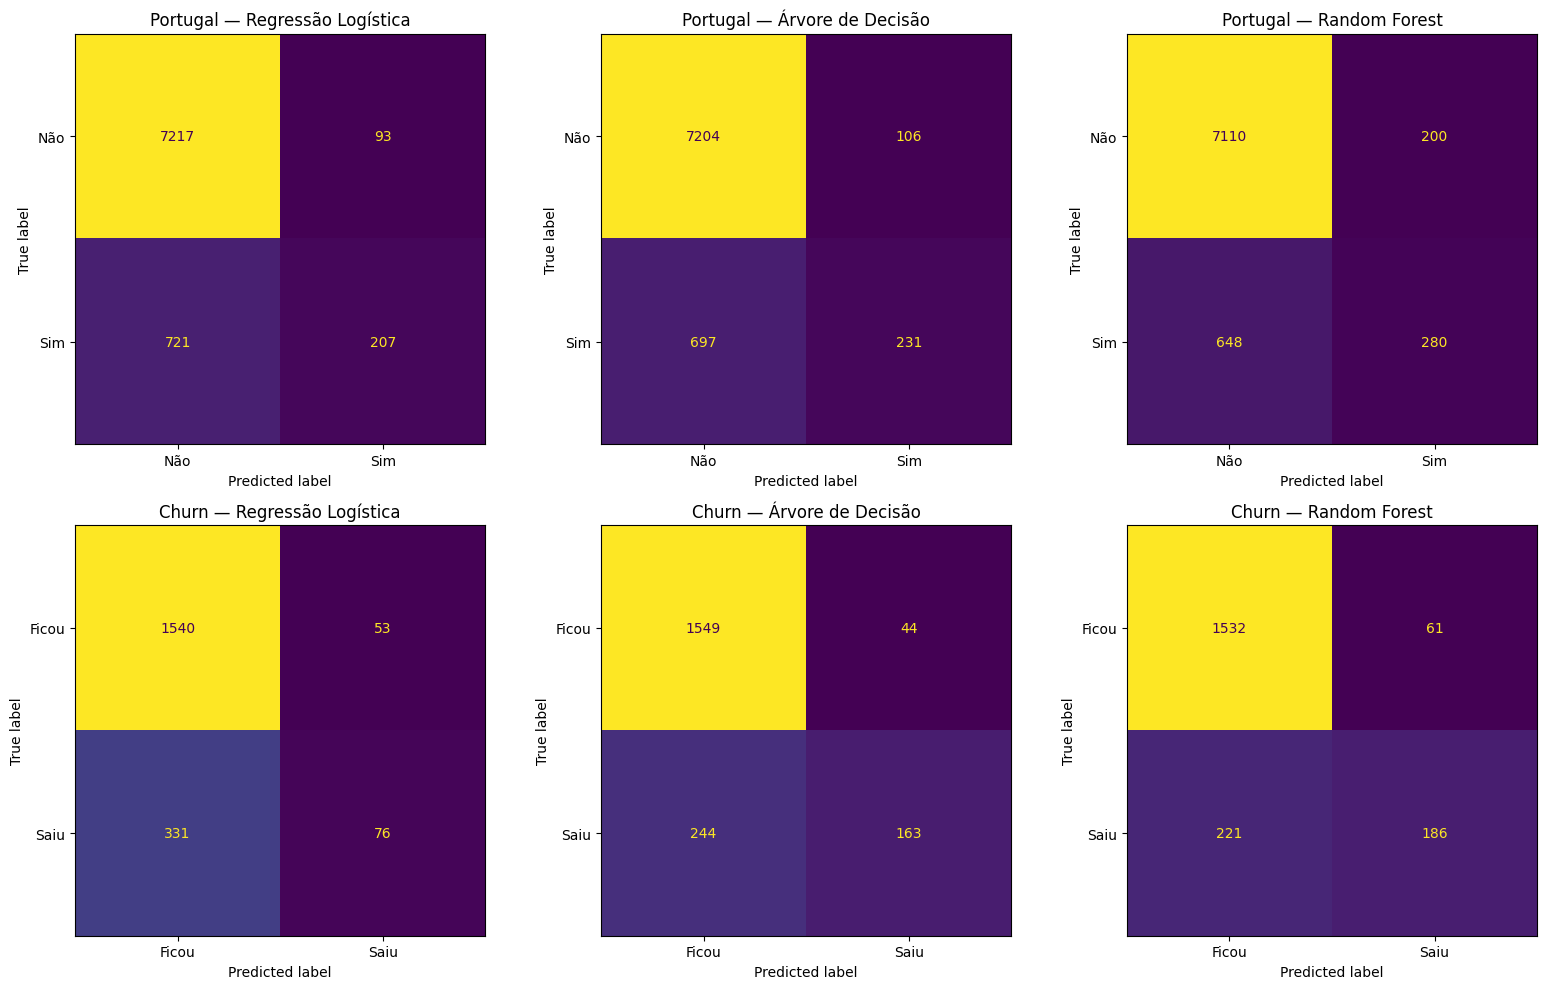

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

modelos_nomes = ['Regressão Logística', 'Árvore de Decisão', 'Random Forest']
modelos_lista_pt = [lr_pt, dt_pt, rf_pt]
modelos_lista_churn = [lr_churn, dt_churn, rf_churn]

for i, (nome, modelo) in enumerate(zip(modelos_nomes, modelos_lista_pt)):
    y_pred = modelo.predict(X_test_pt)
    cm = confusion_matrix(y_test_pt, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Não', 'Sim']).plot(ax=axes[0, i], colorbar=False)
    axes[0, i].set_title(f'Portugal — {nome}')

for i, (nome, modelo) in enumerate(zip(modelos_nomes, modelos_lista_churn)):
    y_pred = modelo.predict(X_test_churn)
    cm = confusion_matrix(y_test_churn, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Ficou', 'Saiu']).plot(ax=axes[1, i], colorbar=False)
    axes[1, i].set_title(f'Churn — {nome}')

plt.tight_layout()
plt.savefig('../figuras/matrizes_confusao.png', dpi=150)
plt.show()

Análise de Viés
Disparate Impact — Taxa de predição positiva por grupo

In [24]:
import numpy as np

# reconstruir os dataframes de teste com as colunas originais
# Portugal — usar o melhor modelo (Random Forest)
y_pred_pt = rf_pt.predict(X_test_pt)

# recuperar índices do teste
idx_test_pt = y_test_pt.index

# análise por faixa etária — Portugal
df_pt_original = pd.read_csv('../dados/Bank Marketing/bank-additional-full.csv', sep=';')
df_pt_original = df_pt_original.drop(columns=['duration'])
df_pt_original['y'] = df_pt_original['y'].map({'yes': 1, 'no': 0})
df_pt_original['faixa_etaria'] = pd.cut(df_pt_original['age'], 
bins=[18,30,40,50,60,100],
labels=['18-30','31-40','41-50','51-60','60+'])

df_teste_pt = df_pt_original.loc[idx_test_pt].copy()
df_teste_pt['y_pred'] = y_pred_pt

print("=== PORTUGAL — Taxa de predição positiva por Faixa Etária ===")
resultado_pt = df_teste_pt.groupby('faixa_etaria', observed=True)['y_pred'].mean().round(3)
print(resultado_pt)

# Churn — usar o melhor modelo (Random Forest)
y_pred_churn = rf_churn.predict(X_test_churn)
idx_test_churn = y_test_churn.index

df_churn_original = pd.read_csv('../dados/Churn/Churn_Modelling.csv')
df_teste_churn = df_churn_original.loc[idx_test_churn].copy()
df_teste_churn['y_pred'] = y_pred_churn

print("\n=== CHURN — Taxa de predição positiva por Gênero ===")
print(df_teste_churn.groupby('Gender')['y_pred'].mean().round(3))

print("\n=== CHURN — Taxa de predição positiva por Geografia ===")
print(df_teste_churn.groupby('Geography')['y_pred'].mean().round(3))

=== PORTUGAL — Taxa de predição positiva por Faixa Etária ===
faixa_etaria
18-30    0.091
31-40    0.045
41-50    0.032
51-60    0.047
60+      0.397
Name: y_pred, dtype: float64

=== CHURN — Taxa de predição positiva por Gênero ===
Gender
Female    0.156
Male      0.095
Name: y_pred, dtype: float64

=== CHURN — Taxa de predição positiva por Geografia ===
Geography
France     0.081
Germany    0.242
Spain      0.088
Name: y_pred, dtype: float64


Cálculo do Disparate Impact

In [25]:
# Disparate Impact = taxa grupo minoritário / taxa grupo majoritário
# Regra: se < 0.8, há discriminação (80% rule)

print("=== DISPARATE IMPACT ===")
print("(valores abaixo de 0.8 indicam discriminação)\n")

# Portugal — Idade (60+ vs 41-50)
di_idade = 0.032 / 0.397
print(f"Portugal — Idade (41-50 vs 60+): {di_idade:.3f}")

# Churn — Gênero (Homem vs Mulher)
di_genero = 0.095 / 0.156
print(f"Churn — Gênero (Homem vs Mulher): {di_genero:.3f}")

# Churn — Geografia (França vs Alemanha)
di_geo = 0.081 / 0.242
print(f"Churn — Geografia (França vs Alemanha): {di_geo:.3f}")

print("\n=== INTERPRETAÇÃO ===")
for nome, valor in [("Portugal Idade", di_idade), 
                     ("Churn Gênero", di_genero), 
                     ("Churn Geografia", di_geo)]:
    status = "DISCRIMINAÇÃO DETECTADA" if valor < 0.8 else "Dentro do limite"
    print(f"{nome}: {valor:.3f} — {status}")

=== DISPARATE IMPACT ===
(valores abaixo de 0.8 indicam discriminação)

Portugal — Idade (41-50 vs 60+): 0.081
Churn — Gênero (Homem vs Mulher): 0.609
Churn — Geografia (França vs Alemanha): 0.335

=== INTERPRETAÇÃO ===
Portugal Idade: 0.081 — DISCRIMINAÇÃO DETECTADA
Churn Gênero: 0.609 — DISCRIMINAÇÃO DETECTADA
Churn Geografia: 0.335 — DISCRIMINAÇÃO DETECTADA


Visualização do Disparate Impact

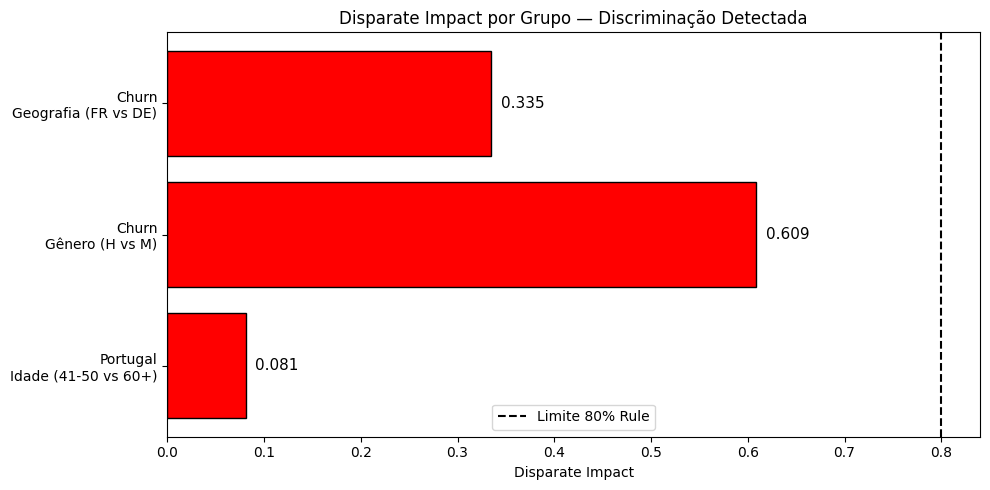

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))

categorias = ['Portugal\nIdade (41-50 vs 60+)', 
              'Churn\nGênero (H vs M)', 
              'Churn\nGeografia (FR vs DE)']
valores = [0.081, 0.609, 0.335]
cores = ['red' if v < 0.8 else 'green' for v in valores]

bars = ax.barh(categorias, valores, color=cores, edgecolor='black')
ax.axvline(x=0.8, color='black', linestyle='--', linewidth=1.5, label='Limite 80% Rule')
ax.set_xlabel('Disparate Impact')
ax.set_title('Disparate Impact por Grupo — Discriminação Detectada')
ax.legend()

for bar, val in zip(bars, valores):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=11)

plt.tight_layout()
plt.savefig('../figuras/disparate_impact.png', dpi=150)
plt.show()